# Define three metric / semi-metric

In [1]:
from scipy.special import rel_entr
from scipy.stats import kstest
from scipy.stats import wasserstein_distance
from scipy.stats import norm
from scipy.stats import uniform
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [2]:
def get_sampled_element(myCDF, xx):
    a = np.random.uniform(0, 1)
    return xx[np.argmax(myCDF>=a)-1]


In [7]:
def get_three_measure(pdf, xx, dx):
    cdf = np.zeros_like(pdf)
    cdf = np.cumsum(pdf*dx)
    pdfUniform = baseline*np.ones(len(xx))
    cdfUniform = np.cumsum(pdfUniform*dx)
    KL = rel_entr(pdfUniform, pdf).sum()
    KS = np.max(np.abs(cdf-cdfUniform))
    Wasser = np.sum(np.abs(cdf-cdfUniform))
    print([KL, KS, Wasser])
#     return KL, KS, Wasser


# Special  case 1 to rule out Wasserstein distance

[14.975197460963017, 0.049998411207917315, 29.99837576018528]
[14.9751974961437, 0.04999886480071336, 22.499278357589425]


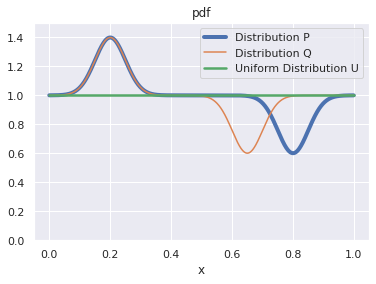

In [8]:
amp = 0.05
baseline = 1
wid = 0.05
center1 = 0.2
center2 = 0.8
dx = 0.001
xx = np.arange(0, 1, dx)
pdfP = amp*norm(center1, wid).pdf(xx) - amp*norm(center2, wid).pdf(xx) + baseline
pdfP = pdfP/np.mean(pdfP)
cdfP = np.zeros_like(pdfP)
cdfP = np.cumsum(pdfP*dx)
plt.plot(xx, pdfP, label='Distribution P', linewidth=4.0)

pdfQ = amp*norm(center1, wid).pdf(xx) - amp*norm(center2-0.15, wid).pdf(xx) + baseline
pdfQ = pdfQ/np.mean(pdfQ)
cdfQ = np.zeros_like(pdfQ)
cdfQ = np.cumsum(pdfQ*dx)
plt.plot(xx, pdfQ, label='Distribution Q', linewidth=1.5)

pdfUniform = baseline*np.ones(len(xx))
cdfUniform = np.zeros_like(pdfUniform)
cdfUniform = np.cumsum(pdfUniform*dx)
plt.plot(xx, pdfUniform, label='Uniform Distribution U', linewidth=2.5)

plt.xlabel('x')
plt.title('pdf')
plt.legend()
plt.ylim(0, 1.5)

get_three_measure(pdfP, xx, dx)
get_three_measure(pdfQ, xx, dx)

# Special case 2 to rule out KL divergence

[6.299342787255611, 0.04999999999999738, 20.049999999996647]
[6.221884175486574, 0.003207051762938451, 1.2387821955472913]


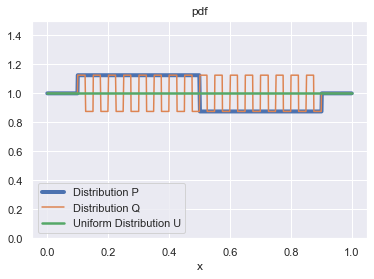

In [5]:
amp = 0.05
baseline = 1
wid = 0.4
center1 = 0.1
center2 = 0.6
dx = 0.001
xx = np.arange(0, 1, dx)
pdfP = amp*uniform(0.1, wid).pdf(xx) - amp*uniform(0.5, wid).pdf(xx) + baseline
pdfP = pdfP/np.mean(pdfP)
cdfP = np.zeros_like(pdfP)
cdfP = np.cumsum(pdfP*dx)
plt.plot(xx, pdfP, label='Distribution P', linewidth=4.0)

num_partition = 16
wid /= num_partition
amp /= num_partition
pdfQ = baseline*np.ones_like(xx)
for i in range(num_partition):
    pdfQ += amp*uniform(0.1+i*wid*2, wid).pdf(xx) - amp*uniform(0.1+i*wid*2+wid, wid).pdf(xx) 

pdfQ = pdfQ/np.mean(pdfQ)
cdfQ = np.zeros_like(pdfQ)
cdfQ = np.cumsum(pdfQ*dx)
plt.plot(xx, pdfQ, label='Distribution Q', linewidth=1.5)

pdfUniform = baseline*np.ones(len(xx))
cdfUniform = np.zeros_like(pdfUniform)
cdfUniform = np.cumsum(pdfUniform*dx)
plt.plot(xx, pdfUniform, label='Uniform Distribution U', linewidth=2.5)

plt.xlabel('x')
plt.title('pdf')
plt.legend()
plt.ylim(0, 1.5)

get_three_measure(pdfP, xx, dx)
get_three_measure(pdfQ, xx, dx)

[6.299342787255611, 0.04999999999999738, 20.049999999996647]


[6.221884175486574, 0.003207051762938451, 1.2387821955472913]


# Special case 3 to rule out ???

[41.76156291618035, 0.06601025532402488, 39.27978124558577]
[106.88843268612482, 0.10726667377312002, 63.82964980316166]


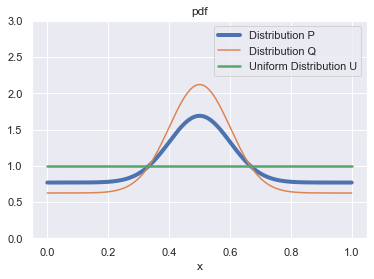

In [6]:
amp = 0.3
baseline = 1
wid = 0.1
center1 = 0.5
center2 = 0.5
dx = 0.001
xx = np.arange(0, 1, dx)
pdfP = amp*norm(center1, wid).pdf(xx) + baseline
pdfP = pdfP/np.mean(pdfP)
cdfP = np.zeros_like(pdfP)
cdfP = np.cumsum(pdfP*dx)
plt.plot(xx, pdfP, label='Distribution P', linewidth=4.0)

pdfQ = 2*amp*norm(center2, wid).pdf(xx) + baseline
pdfQ = pdfQ/np.mean(pdfQ)
cdfQ = np.zeros_like(pdfQ)
cdfQ = np.cumsum(pdfQ*dx)
plt.plot(xx, pdfQ, label='Distribution Q', linewidth=1.5)

pdfUniform = baseline*np.ones(len(xx))
cdfUniform = np.zeros_like(pdfUniform)
cdfUniform = np.cumsum(pdfUniform*dx)
plt.plot(xx, pdfUniform, label='Uniform Distribution U', linewidth=2.5)

plt.xlabel('x')
plt.title('pdf')
plt.legend()
plt.ylim(0, 3)

get_three_measure(pdfP, xx, dx)
get_three_measure(pdfQ, xx, dx)

# Real cases